In [34]:
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
tickers = [
    "SAP.DE",
    "SIE.DE",
    "ALV.DE",
    "DBK.DE",
    "BMW.DE",
    "VOW3.DE",
    "BAS.DE",
    "ADS.DE",
    "IFX.DE",
    "DTG.DE"
]

In [36]:
data = yf.download(tickers, start="2022-01-01", end="2024-12-31")["Close"]

[*********************100%***********************]  10 of 10 completed


In [37]:
returns = data.pct_change()

features = pd.DataFrame()

features["Rendite"] = returns.mean()
features["Volatilität"] = returns.std()

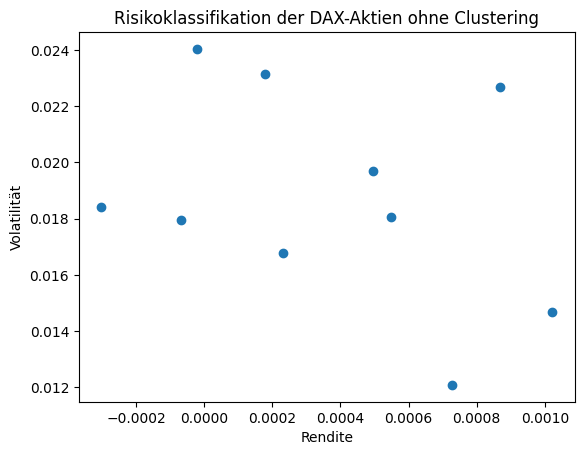

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto")
labels = kmeans.fit_predict(X_scaled)

features["Cluster"] = labels


plt.figure()
plt.scatter(features["Rendite"], features["Volatilität"])
plt.xlabel("Rendite")
plt.ylabel("Volatilität")
plt.title("Risikoklassifikation der DAX-Aktien ohne Clustering")
plt.show()


In [ ]:
cluster_means = features.groupby("Cluster").mean()
cluster_means["Rendite"].plot(kind="bar")

plt.xlabel("Cluster")
plt.ylabel("Durchschnittliche Rendite")
plt.title("Rendite pro Cluster")

plt.show()

,Rendite,Volatilität
Cluster,,
0,0.000536,0.019303
1,0.000875,0.013390
2,-0.000053,0.020886


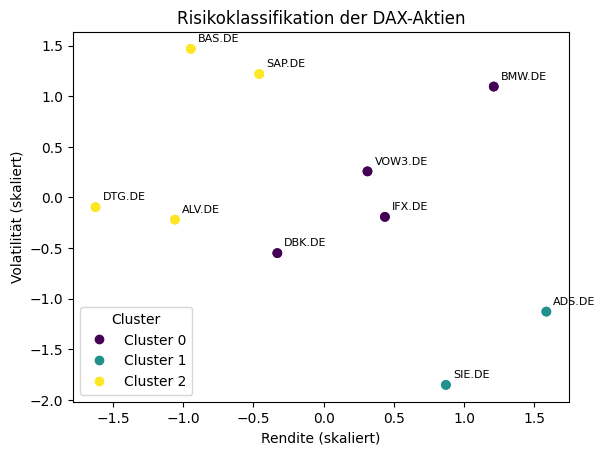

In [39]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.xlabel("Rendite (skaliert)")
plt.ylabel("Volatilität (skaliert)")
plt.title("Risikoklassifikation der DAX-Aktien")
scatter = plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    cmap="viridis"
)
for i, ticker in enumerate(tickers):
    plt.annotate(
        ticker,
        (X_scaled[i, 0], X_scaled[i, 1]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )
handles, _ = scatter.legend_elements()
plt.legend(handles, ["Cluster 0", "Cluster 1", "Cluster 2"], title="Cluster")
plt.show()